<a href="https://colab.research.google.com/github/UmaMaheshwari225a3/DataScience_Task/blob/main/Zomato_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing library pandas, numpy, matplotlib and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Task 1:** Data Understanding & Cleaning

1. Dataset Exploration

In [ ]:
!file /content/zomato_rest_data.xlsx

/content/zomato_rest_data.xlsx: Microsoft Excel 2007+


Loading the dataset

In [ ]:
df = pd.read_excel('/content/zomato_rest_data.xlsx')

In [ ]:
#Display first 5 rows
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
#Display shape of dataset (rows and columns)
df.shape

(51717, 18)

In [ ]:
#List column names
df.columns

Index(['Unnamed: 0', 'url', 'address', 'name', 'online_order', 'book_table',
       'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked',
       'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
#Check data type
df.dtypes


,0
Unnamed: 0,int64
url,object
address,object
name,object
online_order,object
book_table,object
rate,object
votes,int64
phone,object
location,object


In [ ]:
#Identify missing values
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


2. Data Cleaning

In [ ]:
#Remove duplicate records
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
#Handle missing values appropriately
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


In [ ]:
#rate
df['rate'].unique()
df['rate'] = df['rate'].fillna(df['rate'].mode()[0])
#Clean the rating column (remove “NEW”, “-”, etc.)
df['rate'] = df['rate'].str.replace('NEW','')
df['rate'] = df['rate'].str.replace('-','')
#Replacing empty string with null values
df['rate'] = df['rate'].replace('', np.nan)
#Filling null values with mode
df['rate'] = df['rate'].fillna(df['rate'].mode()[0])
#Removing /5
df['rate'] = df['rate'].str.replace('/5', '')
#Rating column to numeric
df['rate'] = df['rate'].astype(float)
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

Removing unnecessary columns

In [ ]:
#Phone
#Drop column
df = df.drop('phone', axis=1,errors='ignore')
df = df.drop(['Unnamed: 0','url','address', 'location', 'reviews_list', 'menu_item'], axis=1, errors='ignore')

In [ ]:
#Renaming column listed_in(type) to Location
df.rename(columns={'listed_in(city)':'Location'}, inplace=True)
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'rest_type',
       'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'Location'],
      dtype='object')

In [ ]:
df.columns

Index(['url', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
#Cost column to numeric (remove commas if present)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',','')
#Converting to float
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)
#Filling null values with mean
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].mean())

In [ ]:
#rest_type
df['rest_type'].isnull().sum()
#Drop column rest_type
df = df.drop('rest_type', axis=1)

In [ ]:
#dish_liked
print(df['dish_liked'].isnull().sum())
print(df['dish_liked'].isnull().sum() / len(df) * 100)
#Approximately 54% of values in dish_liked are empty. So drop the column
df = df.drop('dish_liked', axis=1)

28078
54.29162557766305


In [ ]:
#cuisines
#Filling null values with mode
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])

**Task 2:** Univariate Analysis

1. Top 5 locations with highest number of restaurants




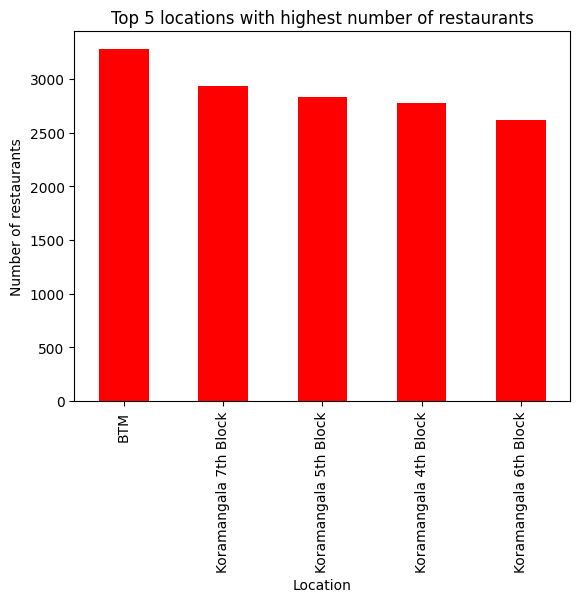

In [ ]:
top5 = df.groupby('Location')['name'].count().sort_values(ascending=False).head()
#Bar chart is used to easily compare the number of restraunts
top5.plot(kind='bar', color = 'red')
#Used to give title
plt.title('Top 5 locations with highest number of restaurants')
#Used for xlabel
plt.xlabel('Location')
#Used for ylabel
plt.ylabel('Number of restaurants')

plt.show()

BTM location has the highest no. of restraunts more than 3000.

The top 5 restraunts are mostly in the location of Koramangala.

2. Distribution of restaurant ratings

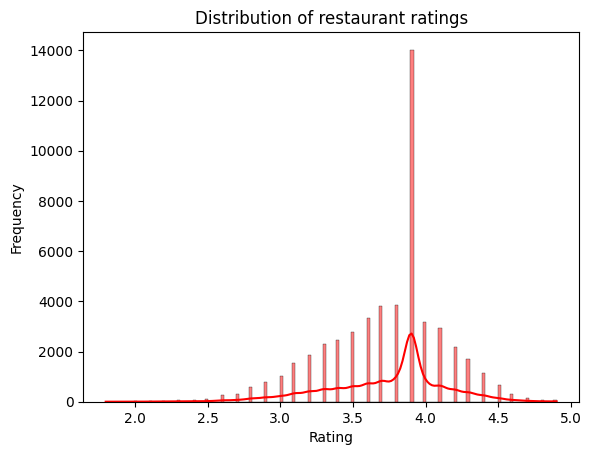

In [ ]:
plt.figure()
# Plot histogram to show distribution of restaurant ratings
sns.histplot(df['rate'], color='red', kde=True)
# Set title of the chart
plt.title('Distribution of restaurant ratings')
# Label for x-axis
plt.xlabel('Rating')
# Label for y-axis
plt.ylabel('Frequency')
# Display the plot
plt.show()

In the rating distribution the rating between 3.5 and 4 has the highest frequency.

Very few have 5 rating and 2 rating.

3. Percentage of restaurants offering online orders

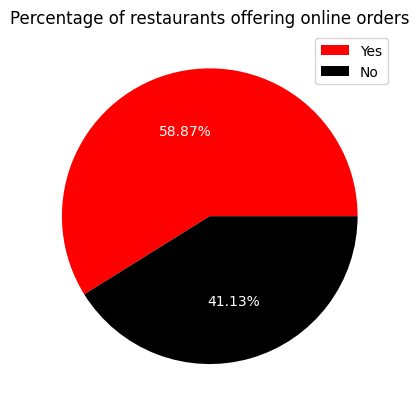

In [ ]:
#Pie chart is used to show the percentage as a whole
plt.pie(df['online_order'].value_counts(), labels=df['online_order'].value_counts().index, autopct='%1.2f%%', colors=['red', 'black'],textprops={'color': 'white'})
plt.title('Percentage of restaurants offering online orders')
plt.legend()
# Display the plot
plt.show()

Approximately 60% restraunts are taking online orders.

4. Distribution of average cost for two


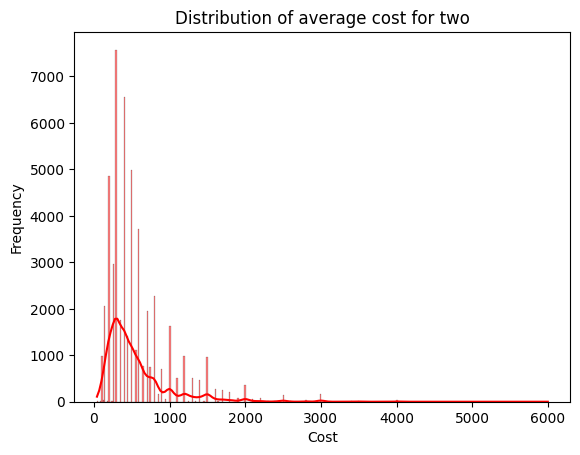

In [ ]:
# Plot histogram to show distribution of average cost for two
sns.histplot(df['approx_cost(for two people)'], color='red', kde=True)
#Set the title
plt.title("Distribution of average cost for two")
# Label for x-axis
plt.xlabel("Cost")
# Label for y-axis
plt.ylabel("Frequency")
plt.show()

The approximate cost for two people is 400-500

**Task 3:** Bivariate Analysis

Rating vs Cost


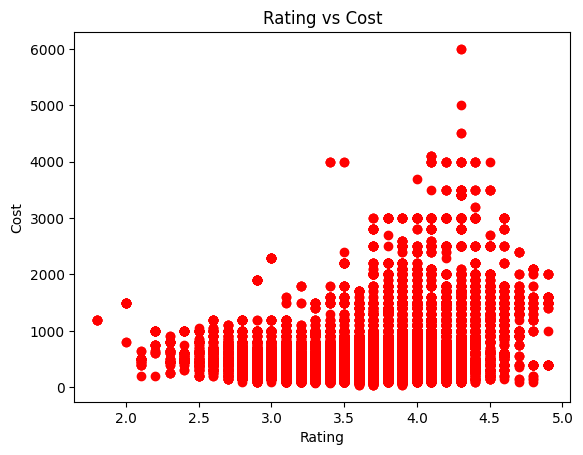

In [ ]:
#Scatter plot is used because there are many values in rate and approx_cost(for two people) columns
plt.scatter(df['rate'], df['approx_cost(for two people)'], color='red')
#Set the title
plt.title('Rating vs Cost')
# Label for x-axis
plt.xlabel('Rating')
# Label for y-axis
plt.ylabel('Cost')
plt.show()

The restaunts with highest cost have approximate rating 4.3-4.4.

Rating vs Online Order


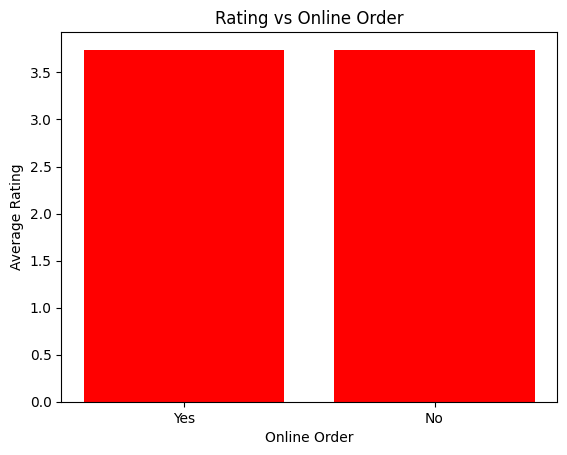

In [ ]:
plt.bar(df['online_order'].unique(), df.groupby('online_order')['rate'].mean(), color=['red','red'])
#Title of chart
plt.title('Rating vs Online Order')
# Label for x-axis
plt.xlabel('Online Order')
# Label for y-axis
plt.ylabel('Average Rating')
plt.show()

The average rating for restraunts taking online orders is approximately same. This means taking online orders does not significantly impact the rating.

Votes vs Rating

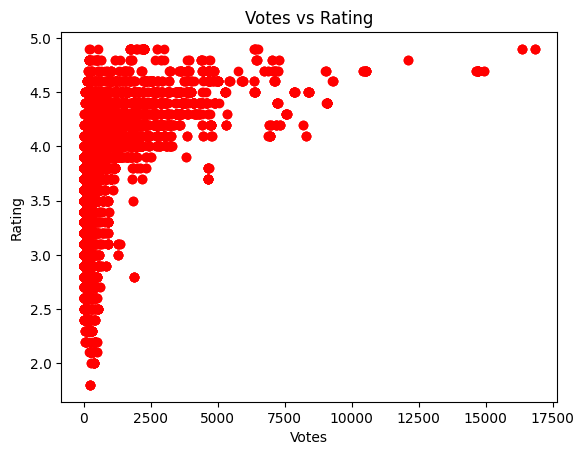

In [ ]:
plt.scatter(df['votes'], df['rate'], color='red')
#Title of chart
plt.title('Votes vs Rating')
# Label for x-axis
plt.xlabel('Votes')
# Label for y-axis
plt.ylabel('Rating')
plt.show()

The most number of votes given is approximately 17,500 with rating of 4.5-5.0.

**Task 4:** Business Insights & Recommendations

1. Does higher cost lead to higher ratings?

    Yes, higher cost leads to higher rating. In the rating plot we have observed that the restaunts with highest cost have approximate rating 4.3-4.4. Therefore, rating increases with restraunt.

2. Does offering online order impact ratings?

    No, offering online order does not impact ratings as we have observed in the bar chart.

3. Which location appears highly competitive?

    BTM, Koramangala locations are highly competitive as there are more number of restraunts there.


4. Where would you recommend opening a new restaurant?

    Open a new restraunt where there is less number of restraunts which is not very competitive.
    New BEL road is a good location for opening a new restraunt.

In [ ]:
df.to_csv('cleaned_zomato_data.csv')